# Análise de Presenças — Catanduva vs unidades de comparação

Compara **Catanduva** com: Mogi das Cruzes, Piracicaba, Presidente Prudente,
Registro, São José do Rio Preto e Taubaté.

**Fontes:**
- `lake_gold_fatos` → `base_all`, `dim_unidade`, `dim_calendario`
- `lake_prep_stat`  → `raw_stat_pessoas_hist`

**Métricas:** presenças (stat), ações (Siplan) e sessões (Siplan)

**Análises:**
1. Totais anuais: 2017, 2018, 2019, 2023, 2024, 2025
2. Recorte 1º trimestre (jan–mar) + Q1 2026
3. *(próxima etapa)* Recortes por tipologia de espaço

---

### Execução local (VS Code)
```
pip install pyodbc azure-identity pandas numpy matplotlib
```
Também é necessário o **ODBC Driver 18 for SQL Server** da Microsoft (instalar uma vez).
O notebook abre um popup de login Microsoft ao rodar a célula de ambiente.

In [141]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10,
})

# ── Workspace Fabric (só usado no modo local / VS Code) ───────────────────
WORKSPACE_NAME = 'ab5f231b-0d65-4a82-9fa3-e490336e912c'  # ← ajuste: nome ou GUID do workspace

# ── Anos de análise ───────────────────────────────────────────────────────
ANOS_ANALISE  = [2017, 2018, 2019, 2023, 2024, 2025]
ANO_RECORTE   = 2026
ANOS_COMPLETO = ANOS_ANALISE + [ANO_RECORTE]

# ── Unidades ──────────────────────────────────────────────────────────────
UNIDADE_FOCO  = 'Catanduva'
UNIDADES_COMP = [
    'Mogi Das Cruzes',
    'Piracicaba',
    'Prudente',
    'Registro',
    'Rio Preto',
    'Taubaté',
]
TODAS_UNIDADES = [UNIDADE_FOCO] + UNIDADES_COMP

CORES = [
    '#E63946',  # Catanduva — vermelho (foco)
    '#457B9D',  # Mogi das Cruzes
    '#2A9D8F',  # Piracicaba
    '#E9C46A',  # Presidente Prudente
    '#F4A261',  # Registro
    '#264653',  # São José do Rio Preto
    '#A8DADC',  # Taubaté
]
COR_MAP = dict(zip(TODAS_UNIDADES, CORES))

In [142]:
# ── Detecção de ambiente: Fabric (spark predefinido) vs local (VS Code) ───
try:
    spark  # noqa — existe somente no Fabric / Synapse
    _FABRIC = True
    print('Ambiente: Microsoft Fabric (PySpark)')
except NameError:
    _FABRIC = False
    print('Ambiente: local / VS Code')

    import struct
    import pyodbc
    from azure.identity import InteractiveBrowserCredential, DeviceCodeCredential

    SQL_ENDPOINT = (
        'beu5bmmdbuwedpv62ucm524jzi-dmrv7k3fbwbevh5d4sidg3urfq'
        '.datawarehouse.fabric.microsoft.com'
    )

    try:
        _cred  = InteractiveBrowserCredential()
        _token = _cred.get_token('https://database.windows.net/.default').token
        print('  ✓ autenticado via browser')
    except Exception as _e:
        print(f'  browser falhou ({_e}), usando device code...')
        _cred  = DeviceCodeCredential()
        _token = _cred.get_token('https://database.windows.net/.default').token
        print('  ✓ autenticado via device code')

    _tb  = _token.encode('utf-16-le')
    _ts  = struct.pack(f'<I{len(_tb)}s', len(_tb), _tb)

    _conn = pyodbc.connect(
        'DRIVER={ODBC Driver 17 for SQL Server};'
        f'SERVER={SQL_ENDPOINT};'
        'Encrypt=Yes;',
        attrs_before={1256: _ts},
    )
    print(f'  ✓ conectado: {SQL_ENDPOINT}')

    def _sql(query: str) -> pd.DataFrame:
        return pd.read_sql(query, _conn)


# ── Funções de leitura unificadas ─────────────────────────────────────────

def _run(query: str) -> pd.DataFrame:
    if _FABRIC:
        df = spark.sql(query).toPandas()
    else:
        df = _sql(query)
    df.columns = [c.split('.')[-1].lower() for c in df.columns]
    return df


def read_gold(table: str) -> pd.DataFrame:
    return _run(f'SELECT * FROM lake_gold_fatos.dbo.{table}')


# atividade_id é armazenado como float ('72.001', '5.' etc.)
# Conversão segura: FLOAT → BIGINT elimina o ponto decimal antes de extrair dígitos
_UO_EXPR = (
    "CAST(LEFT(CAST(CAST(CAST(atividade_id AS FLOAT) AS BIGINT) AS VARCHAR), 2) AS INT)"
)

# Colunas explícitas compartilhadas entre as duas tabelas de stat.
# raw_stat_pessoas_historico tem 'frequencia'; raw_stat_pessoas não tem (mudança de schema).
# O UNION usa NULL AS frequencia na tabela mais recente para manter compatibilidade.
_STAT_COLS = (
    'atividade_id, sessao_id, dia_sessao, frequencia, '
    'presentes, pessoas, inscritos, evadidos, concluintes, numero, presentes_plenos'
)


def read_stat_pessoas(uo_codes: list, anos: list,
                      col_data: str = 'dia_sessao') -> pd.DataFrame:
    uo_s  = ', '.join(str(c) for c in uo_codes)
    ano_s = ', '.join(str(a) for a in anos)
    return _run(f"""
        -- Histórico (até ~2024): inclui coluna frequencia
        SELECT {_STAT_COLS}, {_UO_EXPR} AS uo
        FROM lake_prep_stat.dbo.raw_stat_pessoas_historico
        WHERE {_UO_EXPR} IN ({uo_s})
          AND YEAR({col_data}) IN ({ano_s})

        UNION ALL

        -- Recente (2025+): sem coluna frequencia — NULL esperado por mudança de schema
        SELECT atividade_id, sessao_id, dia_sessao, NULL AS frequencia,
               presentes, pessoas, inscritos, evadidos, concluintes, numero, presentes_plenos,
               {_UO_EXPR} AS uo
        FROM lake_prep_stat.dbo.raw_stat_pessoas
        WHERE {_UO_EXPR} IN ({uo_s})
          AND YEAR({col_data}) IN ({ano_s})
    """)


def read_base_filtered(uo_codes: list, anos: list) -> pd.DataFrame:
    uo_s  = ', '.join(str(c) for c in uo_codes)
    ano_s = ', '.join(str(a) for a in anos)
    return _run(f"""
        SELECT uo, atividade_id, areaprog, atividade, subatividade, servico,
               linguagem, qt_sessoes, PrimeiraData, status_atividade,
               uso_interno, manutencao, regular
        FROM lake_gold_fatos.dbo.base_all
        WHERE uo IN ({uo_s})
          AND YEAR(PrimeiraData) IN ({ano_s})
    """)

Ambiente: local / VS Code


c:\Users\sergio.seabra\AppData\Local\Programs\Python\Python311\Lib\site-packages\msal\oauth2cli\oauth2.py:408: UserWarning: response_mode='form_post' is recommended for better security. See https://www.rfc-editor.org/rfc/rfc9700.html#section-4.3.1
  warnings.warn(


  ✓ autenticado via browser
  ✓ conectado: beu5bmmdbuwedpv62ucm524jzi-dmrv7k3fbwbevh5d4sidg3urfq.datawarehouse.fabric.microsoft.com


## 1. Dimensões — dim_unidade e dim_calendario

In [143]:
dim_unidade_df    = read_gold('dim_unidade')
dim_calendario_df = read_gold('dim_calendario')

print('=== dim_unidade ===')
print(f'shape: {dim_unidade_df.shape}')
print(dim_unidade_df.dtypes)
print()
print(dim_unidade_df.head(20).to_string())

C:\Users\sergio.seabra\AppData\Local\Temp\ipykernel_26096\2305726149.py:41: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(query, _conn)


=== dim_unidade ===
shape: (46, 4)
macro_regiao    object
unidade         object
uo               int64
tipo1           object
dtype: object

   macro_regiao           unidade  uo             tipo1
0       Capital            14 Bis  49  centro expandido
1       Capital        24 De Maio  52            centro
2       Capital      Av. Paulista  65  centro expandido
3       Capital        Belenzinho  68             leste
4       Capital        Bom Retiro  94            centro
5       Capital               CPF  89            centro
6       Capital       Campo Limpo  91               sul
7       Capital             Carmo  64            centro
8       Capital        Casa Verde  60             norte
9       Capital          Cinesesc  59  centro expandido
10      Capital        Consolação  62            centro
11      Capital           Galeria  46            centro
12      Capital        Interlagos  55         campestre
13      Capital          Ipiranga  57               sul
14      Capital   

## 2. Mapeamento de unidades

Confira os nomes das colunas na saída acima e ajuste as três variáveis `COL_*` se necessário.

In [144]:
# ── Ajuste conforme schema real de dim_unidade ────────────────────────────
COL_NOME_DIM = 'unidade'     # coluna com o nome da unidade
# COL_UOR_DIM  = 'uor_codigo'  # código usado em raw_stat_pessoas_hist
COL_UO_DIM   = 'uo'          # código de 2 dígitos usado em base_all

unidades_df = dim_unidade_df[
    dim_unidade_df[COL_NOME_DIM].isin(TODAS_UNIDADES)
].copy()

print(f'Unidades encontradas: {len(unidades_df)} de {len(TODAS_UNIDADES)}')
nao_encontradas = set(TODAS_UNIDADES) - set(unidades_df[COL_NOME_DIM])
if nao_encontradas:
    print(f'  ATENÇÃO — não encontradas: {nao_encontradas}')
    print(f'  Nomes disponíveis em dim_unidade: {sorted(dim_unidade_df[COL_NOME_DIM].unique())}')
print()
print(unidades_df[[COL_NOME_DIM, COL_UO_DIM]].to_string(index=False))

# UOR_CODES  = unidades_df[COL_UOR_DIM].dropna().tolist()
UO_CODES   = unidades_df[COL_UO_DIM].dropna().tolist()
# UOR_TO_NOME = dict(zip(unidades_df[COL_UOR_DIM], unidades_df[COL_NOME_DIM]))
UO_TO_NOME  = dict(zip(unidades_df[COL_UO_DIM],  unidades_df[COL_NOME_DIM]))

Unidades encontradas: 7 de 7

        unidade  uo
Mogi Das Cruzes  72
      Catanduva  79
     Piracicaba  83
       Prudente  87
       Registro  92
      Rio Preto  84
        Taubaté  81


## 3. Presenças — raw_stat_pessoas_historico

A tabela não tem coluna de código de unidade. O `uo` é derivado dos dois primeiros
dígitos de `atividade_id`, o que permite join direto com `base_all`.

In [145]:
stat_raw = read_stat_pessoas(UO_CODES, ANOS_COMPLETO)

print(f'raw_stat_pessoas_historico (filtrado): {stat_raw.shape}')
print(stat_raw.dtypes)
print()
print(stat_raw.head(3).to_string())

C:\Users\sergio.seabra\AppData\Local\Temp\ipykernel_26096\2305726149.py:41: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(query, _conn)


raw_stat_pessoas_historico (filtrado): (283959, 12)
atividade_id        float64
sessao_id           float64
dia_sessao           object
frequencia          float64
presentes           float64
pessoas             float64
inscritos           float64
evadidos            float64
concluintes         float64
numero              float64
presentes_plenos    float64
uo                    int64
dtype: object

   atividade_id     sessao_id  dia_sessao  frequencia  presentes  pessoas  inscritos  evadidos  concluintes  numero  presentes_plenos  uo
0  7.900000e+13  7.900000e+13  2024-10-17         0.0        0.0      0.0        0.0       0.0          0.0    40.0               0.0  79
1  8.300000e+13  8.300000e+13  2018-06-14         0.0        0.0      0.0        0.0       0.0          0.0    45.0               0.0  83
2  8.700000e+13  8.700000e+13  2023-07-08         0.0        0.0      0.0        0.0       0.0          0.0    45.0               0.0  87


In [146]:
# ── Catanduva 2025 — exploração detalhada de presenças ───────────────────
# Consulta direta ao banco (independente do pipeline acima).
# Agrega presenças por (1) subatividade e (2) subatividade × servico.

_UO_CAT = 79  # Catanduva

_pres25 = _run(f"""
    WITH stat AS (
        SELECT atividade_id, presentes
        FROM lake_prep_stat.dbo.raw_stat_pessoas_historico
        WHERE {_UO_EXPR} = {_UO_CAT} AND YEAR(dia_sessao) = 2026

        UNION ALL

        SELECT atividade_id, presentes
        FROM lake_prep_stat.dbo.raw_stat_pessoas
        WHERE {_UO_EXPR} = {_UO_CAT} AND YEAR(dia_sessao) = 2026
    )
    SELECT
        b.subatividade,
        b.servico,
        COUNT(DISTINCT s.atividade_id) AS acoes,
        SUM(CAST(s.presentes AS BIGINT)) AS presencas
    FROM stat s
    LEFT JOIN lake_gold_fatos.dbo.base_all b
           ON CAST(CAST(s.atividade_id AS BIGINT) AS VARCHAR)
            = CAST(CAST(b.atividade_id AS BIGINT) AS VARCHAR)
    GROUP BY b.subatividade, b.servico
    ORDER BY presencas DESC
""")

_pres25['presencas'] = pd.to_numeric(_pres25['presencas'], errors='coerce').fillna(0).astype(int)
_pres25['acoes']     = pd.to_numeric(_pres25['acoes'],     errors='coerce').fillna(0).astype(int)

# ── 1. Por subatividade ───────────────────────────────────────────────────
_por_sub = (
    _pres25
    .groupby('subatividade', dropna=False)
    [['acoes', 'presencas']]
    .sum()
    .sort_values('presencas', ascending=False)
    .reset_index()
)

print('=== Catanduva 2025 — presenças por subatividade ===')
print(f'Total: {_por_sub["presencas"].sum():,} presenças | {_por_sub["acoes"].sum():,} ações\n')
print(_por_sub.to_string(index=False))

# ── 2. Por subatividade × servico ────────────────────────────────────────
print()
print('=== Catanduva 2025 — presenças por subatividade × serviço ===')
print(_pres25[['subatividade', 'servico', 'acoes', 'presencas']].to_string(index=False))

C:\Users\sergio.seabra\AppData\Local\Temp\ipykernel_26096\2305726149.py:41: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(query, _conn)


=== Catanduva 2025 — presenças por subatividade ===
Total: 104,488 presenças | 232 ações

                    subatividade  acoes  presencas
                  Ações mediadas     61      25827
       Multipráticas recreativas      1      23023
                    Apresentação     45      20445
                 Parque aquático      2       8624
                Ações formativas     41       8363
              Formação esportiva     16       6195
  Exercício físicos sistematicos     18       6167
                        Consulta      5       2213
Acesso a recursos informacionais      1       1367
                         Viagens      3        693
                         Eventos      2        573
                        Exibição      7        302
          Produtos gastronômicos      5        300
       Análise de risco em saúde      2        150
      Sessão diagnóstica/clínica      2        150
                        Passeios      2         80
  Incentivo artístico e cultural      1    

In [147]:
# ── Catanduva 2026 — cobertura de datas na fonte ─────────────────────────

_UO_CAT = 79

_cob26 = _run(f"""
    WITH stat AS (
        SELECT dia_sessao, presentes
        FROM lake_prep_stat.dbo.raw_stat_pessoas_historico
        WHERE {_UO_EXPR} = {_UO_CAT} AND YEAR(dia_sessao) = 2026

        UNION ALL

        SELECT dia_sessao, presentes
        FROM lake_prep_stat.dbo.raw_stat_pessoas
        WHERE {_UO_EXPR} = {_UO_CAT} AND YEAR(dia_sessao) = 2026
    )
    SELECT
        MAX(CAST(dia_sessao AS DATE))                              AS ultima_data,
        COUNT(*)                                                   AS total_linhas,
        SUM(CASE WHEN CAST(presentes AS INT) > 0 THEN 1 ELSE 0 END) AS linhas_com_presenca,
        SUM(CAST(presentes AS BIGINT))                             AS total_presencas
    FROM stat
""")

print('=== Catanduva 2026 — cobertura na fonte ===')
print(_cob26.to_string(index=False))

# Últimas 10 datas com pelo menos 1 presença
_ult26 = _run(f"""
    WITH stat AS (
        SELECT dia_sessao, SUM(CAST(presentes AS BIGINT)) AS presencas
        FROM lake_prep_stat.dbo.raw_stat_pessoas_historico
        WHERE {_UO_EXPR} = {_UO_CAT} AND YEAR(dia_sessao) = 2026
        GROUP BY dia_sessao

        UNION ALL

        SELECT dia_sessao, SUM(CAST(presentes AS BIGINT)) AS presencas
        FROM lake_prep_stat.dbo.raw_stat_pessoas
        WHERE {_UO_EXPR} = {_UO_CAT} AND YEAR(dia_sessao) = 2026
        GROUP BY dia_sessao
    )
    SELECT TOP 10
        CAST(dia_sessao AS DATE) AS dia,
        SUM(presencas)           AS presencas
    FROM stat
    WHERE presencas > 0
    GROUP BY CAST(dia_sessao AS DATE)
    ORDER BY dia DESC
""")

print()
print('Últimas 10 datas com presença > 0:')
print(_ult26.to_string(index=False))

C:\Users\sergio.seabra\AppData\Local\Temp\ipykernel_26096\2305726149.py:41: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(query, _conn)
C:\Users\sergio.seabra\AppData\Local\Temp\ipykernel_26096\2305726149.py:41: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(query, _conn)


=== Catanduva 2026 — cobertura na fonte ===
ultima_data  total_linhas  linhas_com_presenca  total_presencas
 2026-04-25          1917                 1539           104488

Últimas 10 datas com presença > 0:
       dia  presencas
2026-04-25        385
2026-04-24        745
2026-04-23       3177
2026-04-22       2712
2026-04-21        729
2026-04-20         38
2026-04-19       2322
2026-04-18       2330
2026-04-17       1234
2026-04-16       1420


In [148]:
COL_DATA_STAT = 'dia_sessao'          # data da sessão
COL_QTD_STAT  = 'presentes'  # quantidade de presentes

stat_df = stat_raw.copy()
stat_df[COL_DATA_STAT] = pd.to_datetime(stat_df[COL_DATA_STAT], errors='coerce')
stat_df[COL_QTD_STAT]  = pd.to_numeric(stat_df[COL_QTD_STAT],  errors='coerce').fillna(0).astype(int)

stat_df['uo']        = pd.to_numeric(stat_df['uo'], errors='coerce').astype('Int64')
stat_df['unidade']   = stat_df['uo'].map(UO_TO_NOME)
stat_df['ano']       = stat_df[COL_DATA_STAT].dt.year
stat_df['trimestre'] = stat_df[COL_DATA_STAT].dt.quarter

stat_df = stat_df[stat_df['unidade'].notna() & stat_df[COL_DATA_STAT].notna()].copy()

print(f'stat_df pronto: {stat_df.shape}')
print()
print('Presentes por unidade/ano:')
print(
    stat_df.groupby(['unidade', 'ano'])[COL_QTD_STAT]
    .sum().unstack(fill_value=0).to_string()
)

stat_df pronto: (283959, 15)

Presentes por unidade/ano:
ano                2017    2018    2019    2023    2024    2025    2026
unidade                                                                
Catanduva        262460  221101  189140  139269  167583  258837  104488
Mogi Das Cruzes       0       0       0  430061  346593  459329  170230
Piracicaba       369311  349648  355217  245684  247374  348864  128402
Prudente         313550  270446  269039  242755  528533  398260  140948
Registro         120038  125849  237634  152276  147962  274580   99149
Rio Preto        280064  292587  355121  305629  372651  419681  107769
Taubaté          299230  311565  314876  225164  301219  521356  163013


## 4. Ações e sessões — base_all

In [149]:
base_raw = read_base_filtered(UO_CODES, ANOS_COMPLETO)

print(f'base_all (filtrado): {base_raw.shape}')
print(base_raw.dtypes)

C:\Users\sergio.seabra\AppData\Local\Temp\ipykernel_26096\2305726149.py:41: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(query, _conn)


base_all (filtrado): (48449, 13)
uo                           int64
atividade_id               float64
areaprog                    object
atividade                   object
subatividade                object
servico                     object
linguagem                   object
qt_sessoes                 float64
primeiradata        datetime64[ns]
status_atividade            object
uso_interno                  int64
manutencao                 float64
regular                    float64
dtype: object


In [ ]:
base_df = base_raw.copy()

# _run() normaliza todos os nomes para lowercase — usar 'primeiradata', não 'PrimeiraData'
base_df['primeiradata'] = pd.to_datetime(base_df['primeiradata'], errors='coerce')
base_df['qt_sessoes']   = pd.to_numeric(base_df['qt_sessoes'], errors='coerce').fillna(0).astype(int)
base_df['unidade']      = base_df['uo'].map(UO_TO_NOME)
base_df['ano']          = base_df['primeiradata'].dt.year
base_df['trimestre']    = base_df['primeiradata'].dt.quarter

base_df = base_df[base_df['unidade'].notna() & base_df['ano'].notna()].copy()

acoes_df = (
    base_df
    .groupby(['unidade', 'ano'], as_index=False)
    .agg(
        acoes   = ('atividade_id', 'nunique'),
        sessoes = ('qt_sessoes',   'sum'),
    )
)

print('Ações e sessões por unidade/ano:')
print(acoes_df.pivot(index='ano', columns='unidade', values='acoes').to_string())

In [151]:
# ── Filtro para este levantamento ─────────────────────────────────────────
#
# Exclui atividades que não representam oferta pública efetiva:
#   uso_interno = 0  → exclui atividades de uso interno (reuniões, treinamentos, etc.)
#   manutencao  = 0  → exclui atividades classificadas como manutenção de espaços/equipamentos
#   regular     = 0  → exclui atividades regulares/administrativas sem abertura ao público
#
# Mantém somente:
#   status_atividade = 'APROVADO' → apenas atividades aprovadas formalmente no Siplan
#
# O resultado é salvo em base_lev para preservar base_df original.
# Use base_lev no lugar de base_df nas células seguintes deste levantamento.

_cols_flag = ['uso_interno', 'manutencao', 'regular']

# Guarda-chuva: verifica se as colunas vieram no SELECT (dependem de read_base_filtered)
_faltando = [c for c in _cols_flag + ['status_atividade'] if c not in base_df.columns]
if _faltando:
    raise ValueError(
        f'Colunas ausentes em base_df: {_faltando}\n'
        'Confirme que read_base_filtered inclui uso_interno, manutencao e regular no SELECT.'
    )

# Flags podem vir como float (0.0/1.0) do SQL — converte para int
for _col in _cols_flag:
    base_df[_col] = pd.to_numeric(base_df[_col], errors='coerce').fillna(0).astype(int)

_mask = (
    (base_df['uso_interno']                    == 0) &  # não é uso interno
    (base_df['manutencao']                     == 0) &  # não é manutenção
    (base_df['regular']                        == 0) &  # não é atividade regular/adm
    (base_df['status_atividade'].str.upper()   == 'APROVADO')  # somente aprovadas
)

base_lev = base_df[_mask].copy()

_total  = len(base_df)
_filtrado = len(base_lev)
print(f'base_lev (levantamento): {_filtrado:,} de {_total:,} atividades '
      f'({_filtrado / _total:.1%} aproveitadas)')
print()
print('Removidas por critério (podem se sobrepor):')
print(f'  uso_interno = 1   : {(base_df["uso_interno"]                  == 1).sum():>6,}')
print(f'  manutencao  = 1   : {(base_df["manutencao"]                   == 1).sum():>6,}')
print(f'  regular     = 1   : {(base_df["regular"]                      == 1).sum():>6,}')
print(f'  status ≠ APROVADO : {(base_df["status_atividade"].str.upper() != "APROVADO").sum():>6,}')

base_lev (levantamento): 36,910 de 48,449 atividades (76.2% aproveitadas)

Removidas por critério (podem se sobrepor):
  uso_interno = 1   :  6,932
  manutencao  = 1   :     92
  regular     = 1   :  1,487
  status ≠ APROVADO :  4,463


## 5. Consolidação — presenças + ações + sessões

In [152]:
# ── Presenças anuais (de stat) ────────────────────────────────────────────
pres_anual = (
    stat_df
    .groupby(['unidade', 'ano'], as_index=False)[COL_QTD_STAT]
    .sum()
    .rename(columns={COL_QTD_STAT: 'presencas'})
)

# ── Ações e sessões anuais (de base_all) ──────────────────────────────────
acoes_anual = (
    base_df
    .groupby(['unidade', 'ano'], as_index=False)
    .agg(acoes=('atividade_id', 'nunique'), sessoes=('qt_sessoes', 'sum'))
)

# ── Merge das três métricas ───────────────────────────────────────────────
summary_df = pres_anual.merge(acoes_anual, on=['unidade', 'ano'], how='outer')

# ── join stat ↔ base_all via atividade_id (para recortes futuros) ─────────
# Permite agregar presenças por areaprog, subatividade, linguagem etc.
stat_base_df = (
    stat_df[['atividade_id', 'unidade', 'uo', 'ano', 'trimestre', COL_QTD_STAT]]
    .merge(
        base_df[['atividade_id', 'areaprog', 'atividade', 'subatividade', 'linguagem']],
        on='atividade_id', how='left',
    )
)

print('=== Resumo anual — presenças, ações, sessões ===')
for metrica in ['presencas', 'acoes', 'sessoes']:
    pv = (
        summary_df[summary_df['ano'].isin(ANOS_ANALISE)]
        .pivot(index='ano', columns='unidade', values=metrica)
        .reindex(columns=TODAS_UNIDADES)
        .reindex(ANOS_ANALISE)
    )
    print(f'\n--- {metrica.upper()} ---')
    print(pv.applymap(lambda x: f'{int(x):,}' if pd.notna(x) else '—').to_string())

print(f'\nstat_base_df (para recortes): {stat_base_df.shape}')
print('areaprog disponíveis:', sorted(stat_base_df['areaprog'].dropna().unique().tolist()))

=== Resumo anual — presenças, ações, sessões ===

--- PRESENCAS ---
unidade Catanduva Mogi Das Cruzes Piracicaba Prudente Registro Rio Preto  Taubaté
ano                                                                              
2017      262,460               —    369,311  313,550  120,038   280,064  299,230
2018      221,101               —    349,648  270,446  125,849   292,587  311,565
2019      189,140               —    355,217  269,039  237,634   355,121  314,876
2023      139,269         430,061    245,684  242,755  152,276   305,629  225,164
2024      167,583         346,593    247,374  528,533  147,962   372,651  301,219
2025      258,837         459,329    348,864  398,260  274,580   419,681  521,356

--- ACOES ---
unidade Catanduva Mogi Das Cruzes Piracicaba Prudente Registro Rio Preto Taubaté
ano                                                                             
2017          523               —      1,419      720      600     1,392   1,252
2018          723 

## 6. Gráficos — totais anuais

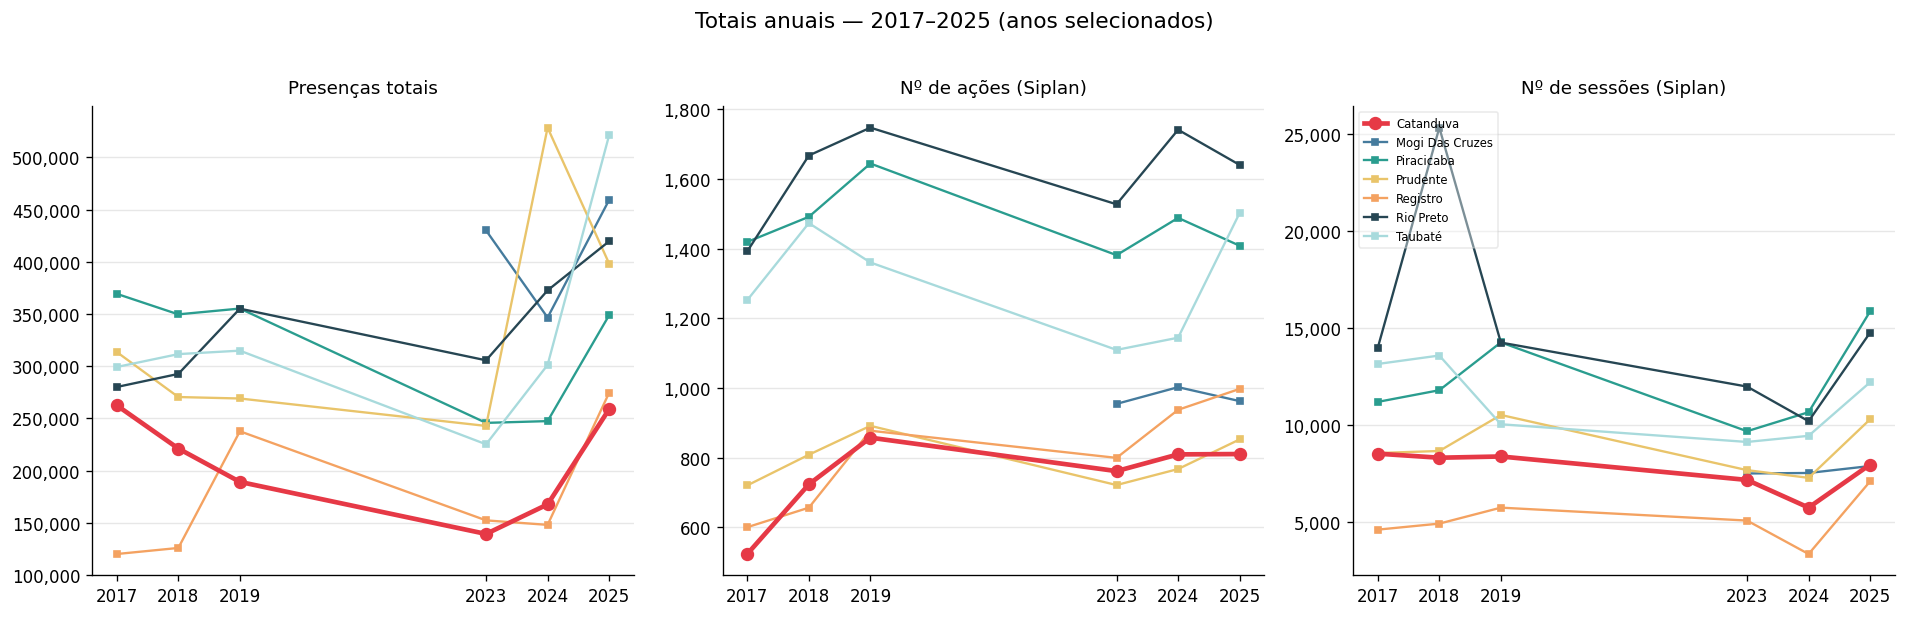

In [153]:
def _plot_metric_lines(pivot: pd.DataFrame, titulo: str, anos: list, ax):
    for unidade in TODAS_UNIDADES:
        if unidade not in pivot.columns:
            continue
        foco = unidade == UNIDADE_FOCO
        ax.plot(
            anos,
            pivot[unidade].reindex(anos),
            label=unidade,
            color=COR_MAP.get(unidade, '#999'),
            linewidth=2.8 if foco else 1.4,
            marker='o' if foco else 's',
            markersize=7 if foco else 4,
            zorder=5 if foco else 3,
        )
    ax.set_title(titulo, fontsize=11, pad=8)
    ax.set_xticks(anos)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))
    ax.grid(axis='y', alpha=0.3)


def _make_pivot(df, anos, metrica):
    return (
        df[df['ano'].isin(anos)]
        .pivot(index='ano', columns='unidade', values=metrica)
        .reindex(columns=TODAS_UNIDADES)
        .reindex(anos)
    )


fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)

for ax, metrica, titulo in zip(
    axes,
    ['presencas', 'acoes', 'sessoes'],
    ['Presenças totais', 'Nº de ações (Siplan)', 'Nº de sessões (Siplan)'],
):
    pv = _make_pivot(summary_df, ANOS_ANALISE, metrica)
    _plot_metric_lines(pv, titulo, ANOS_ANALISE, ax)

# legenda única na última coluna
axes[-1].legend(loc='upper left', fontsize=7, framealpha=0.4)
fig.suptitle('Totais anuais — 2017–2025 (anos selecionados)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 7. Recorte — 1º Trimestre (jan–mar) + Q1 2026

In [154]:
# ── Q1 presenças ──────────────────────────────────────────────────────────
pres_q1 = (
    stat_df[(stat_df['trimestre'] == 1) & (stat_df['ano'].isin(ANOS_COMPLETO))]
    .groupby(['unidade', 'ano'], as_index=False)[COL_QTD_STAT]
    .sum()
    .rename(columns={COL_QTD_STAT: 'presencas'})
)

# ── Q1 ações e sessões (atividades com primeira sessão em Q1) ─────────────
acoes_q1 = (
    base_df[(base_df['trimestre'] == 1) & (base_df['ano'].isin(ANOS_COMPLETO))]
    .groupby(['unidade', 'ano'], as_index=False)
    .agg(
        acoes   = ('atividade_id', 'nunique'),
        sessoes = ('qt_sessoes',   'sum'),
    )
)

q1_df = pres_q1.merge(acoes_q1, on=['unidade', 'ano'], how='outer')

print('=== Resumo Q1 (jan–mar) ===')
for metrica in ['presencas', 'acoes', 'sessoes']:
    pv = (
        q1_df
        .pivot(index='ano', columns='unidade', values=metrica)
        .reindex(columns=TODAS_UNIDADES)
        .reindex(ANOS_COMPLETO)
    )
    print(f'\n--- {metrica.upper()} Q1 ---')
    print(pv.applymap(lambda x: f'{int(x):,}' if pd.notna(x) else '—').to_string())

=== Resumo Q1 (jan–mar) ===

--- PRESENCAS Q1 ---
unidade Catanduva Mogi Das Cruzes Piracicaba Prudente Registro Rio Preto  Taubaté
ano                                                                              
2017       63,366               —    104,142  104,631   32,981    81,124  100,129
2018       57,788               —    102,316   72,950   31,915    89,064   86,976
2019       49,408               —    117,739   87,327   32,548    98,403  110,887
2023       37,104         124,502     50,933   55,482   24,159    67,342   34,606
2024       33,320          95,094     69,273   70,558   26,218    99,781   88,435
2025       50,155         149,133     93,884  119,605   36,861   102,396  132,123
2026       72,004         129,026     93,562  113,844   84,564    89,402  127,837

--- ACOES Q1 ---
unidade Catanduva Mogi Das Cruzes Piracicaba Prudente Registro Rio Preto Taubaté
ano                                                                             
2017          144               

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)

for ax, metrica, titulo in zip(
    axes,
    ['presencas', 'acoes', 'sessoes'],
    ['Presenças — Q1', 'Ações — Q1', 'Sessões — Q1'],
):
    pv = _make_pivot(q1_df, ANOS_COMPLETO, metrica)
    _plot_metric_lines(pv, titulo, ANOS_COMPLETO, ax)
    # Sombra no ano de recorte
    ax.axvspan(ANO_RECORTE - 0.4, ANO_RECORTE + 0.4, color='#fffacd', alpha=0.7, zorder=0)
    ax.text(ANO_RECORTE, ax.get_ylim()[1] * 0.97, f'Q1\n{ANO_RECORTE}',
            ha='center', va='top', fontsize=7, color='#666')

axes[-1].legend(loc='upper left', fontsize=7, framealpha=0.4)
fig.suptitle('1º Trimestre (jan–mar) — comparativo de anos', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 8. Variação de Catanduva — Q1 2026 vs anos anteriores

In [ ]:
cat_q1 = q1_df[q1_df['unidade'] == UNIDADE_FOCO].set_index('ano')

print(f'{UNIDADE_FOCO} — Q1 {ANO_RECORTE}')
print(f"  presenças : {cat_q1.loc[ANO_RECORTE, 'presencas']:>10,.0f}"  if ANO_RECORTE in cat_q1.index else '  presenças : s/d')
print(f"  ações     : {cat_q1.loc[ANO_RECORTE, 'acoes']:>10,.0f}"      if ANO_RECORTE in cat_q1.index else '  ações     : s/d')
print(f"  sessões   : {cat_q1.loc[ANO_RECORTE, 'sessoes']:>10,.0f}"    if ANO_RECORTE in cat_q1.index else '  sessões   : s/d')
print()

if ANO_RECORTE in cat_q1.index:
    ref_p = cat_q1.loc[ANO_RECORTE, 'presencas']
    ref_a = cat_q1.loc[ANO_RECORTE, 'acoes']
    ref_s = cat_q1.loc[ANO_RECORTE, 'sessoes']

    header = f"{'Ano':<6}  {'Presenças base':>14}  {'Δ pres':>8}  {'Ações base':>10}  {'Δ ações':>8}  {'Sessões base':>12}  {'Δ sessões':>9}"
    print(header)
    print('-' * len(header))

    for ano in ANOS_ANALISE:
        if ano not in cat_q1.index:
            continue
        row = cat_q1.loc[ano]

        def _delta(ref, base):
            if pd.notna(base) and base > 0 and pd.notna(ref):
                d = (ref - base) / base * 100
                return f'{("+" if d >= 0 else "")}{d:.1f}%'
            return 's/d'

        print(
            f"{ano:<6}  {row['presencas']:>14,.0f}  "
            f"{_delta(ref_p, row['presencas']):>8}  "
            f"{row['acoes']:>10,.0f}  "
            f"{_delta(ref_a, row['acoes']):>8}  "
            f"{row['sessoes']:>12,.0f}  "
            f"{_delta(ref_s, row['sessoes']):>9}"
        )

## 9. *(Próxima etapa)* Recortes por tipologia de espaço

Prévia da distribuição por área programática em `base_all` para orientar
o recorte seguinte.

In [ ]:
if 'areaprog' in base_df.columns:
    pv = (
        base_df[base_df['ano'].isin(ANOS_ANALISE)]
        .groupby(['unidade', 'areaprog'])['atividade_id']
        .nunique()
        .unstack(fill_value=0)
    )
    print('Ações por unidade × área programática (anos de análise):')
    print(pv.to_string())
    print()
    print('Colunas de tipologia disponíveis em base_all:')
    for col in ['areaprog', 'atividade', 'subatividade', 'linguagem', 'formato']:
        if col in base_df.columns:
            vals = base_df[col].dropna().unique()
            print(f'  {col}: {sorted(vals[:15])} {"..." if len(vals) > 15 else ""}')
else:
    print('areaprog não encontrado. Colunas disponíveis:', base_df.columns.tolist())